In [1]:
import pandas

In [2]:
import pandas as pd
df = pd.read_json('corpora/dados_videos_nikolas.json')

In [3]:
# Converte a coluna de data para o tipo correto
df['data_criacao'] = pd.to_datetime(df['data_criacao'])

# Libera o  uso do acessador .dt
df['mes'] = df['data_criacao'].dt.month
df

,id_vd,id_ch,titulo,descricao,data_criacao,views,likes,coments,duracao,transcricao,mes
0,PGTk6LEXkZw,UCxI9vN6UbxmBt8VIvUKtJaA,DUAS CRIANÇAS EST4PR8DAS POR MENORES - ATÉ QUA...,,2026-05-06,20033,8357,464,216,,5
1,MKC1-xmTJ8Q,UCxI9vN6UbxmBt8VIvUKtJaA,SAIBA QUEM É MESSIAS: O INDICADO AO STF POR LULA,,2026-04-28,569518,109182,6361,356,,4
2,3JPyYn5evjk,UCxI9vN6UbxmBt8VIvUKtJaA,NIKOLAS RESPONDE ESQUERDISTA SOBRE SEU TRABALHO,,2026-04-25,117465,28378,2024,280,,4
3,nX7IClY7zmA,UCxI9vN6UbxmBt8VIvUKtJaA,NIKOLAS CONVOCA JOVENS PRA TIRAR TÍTULO DE ELE...,,2026-04-12,251170,45946,2983,154,,4
4,5GBnT-Nhn64,UCxI9vN6UbxmBt8VIvUKtJaA,NIKOLAS VAI PRA CIMA DE ALCOLUMBRE,,2026-04-02,472922,120811,6916,267,,4
...,...,...,...,...,...,...,...,...,...,...,...
470,UKhzsqyviBc,UCxI9vN6UbxmBt8VIvUKtJaA,A cara de PAU de Maduro!,"Socialismo pra vocês, capitalismo pra mim.\n\n...",2018-09-19,17181,2969,97,257,,9
471,eGRnZ0dIUm0,UCxI9vN6UbxmBt8VIvUKtJaA,Escola Sem Partido: PRA QUÊ?!,Instagram: https://instagram.com/nikolasferrei...,2018-08-17,228403,25679,847,343,,8
472,-X0KAxwrw38,UCxI9vN6UbxmBt8VIvUKtJaA,Toda mulher é feminista??!,Inconformado?! CURTA O VÍDEO E INSCREVA-SE NO ...,2018-08-17,43637,6890,648,199,,8
473,Y_nPRRnwdAQ,UCxI9vN6UbxmBt8VIvUKtJaA,Destruindo comunistas - AO VIVAÇO,Instagram: https://instagram.com/nikolasferrei...,2018-08-17,529520,66015,2963,103,,8


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Ordenar por data (importante para séries temporais)
df = df.sort_values('data_criacao')

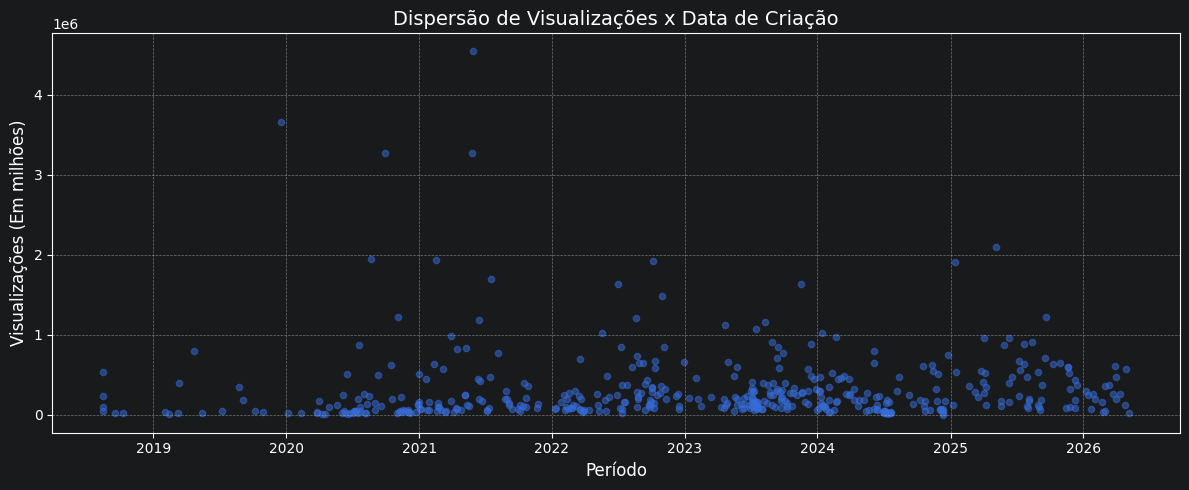

In [5]:
plt.figure(figsize=(12, 5))

# Gerando o gráfico de dispersão
plt.scatter(df['data_criacao'], df['views'], alpha=0.5, s=20)

# Configurações de títulos e rótulos
plt.title('Dispersão de Visualizações x Data de Criação', fontsize=14)
plt.xlabel('Período', fontsize=12)
plt.ylabel('Visualizações (Em milhões)', fontsize=12)

# Melhorar a visualização do eixo X para mostrar meses
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

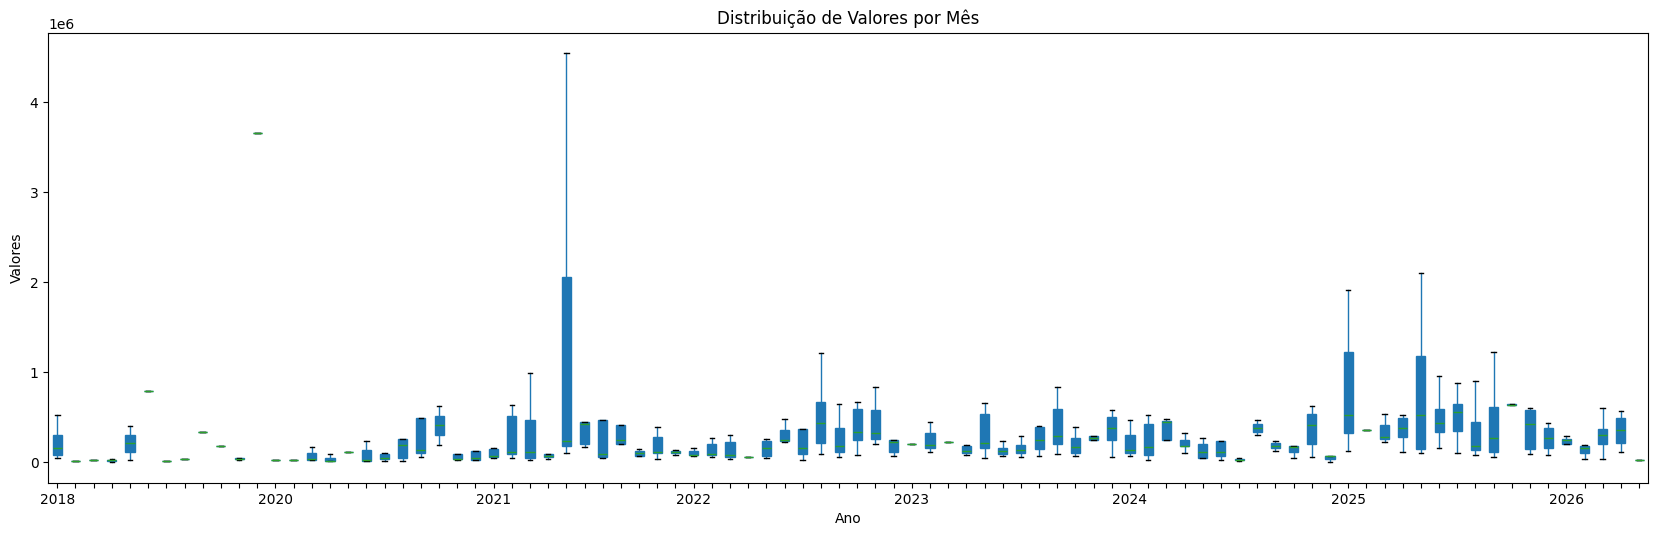

In [31]:
import matplotlib.pyplot as plt

plt.style.use('default')

df['Mes'] = df['data_criacao'].dt.strftime('%Y-%m')

ax = df.boxplot(column='views', by='Mes', grid=False, patch_artist=True, figsize=(20, 6), showfliers=False)

labels = [item.get_text() for item in ax.get_xticklabels()]

new_labels = []
for i, label in enumerate(labels):
    ano, mes = label.split('-')
    if i == 0 or mes == '01':
        new_labels.append(ano)
    else:
        new_labels.append('')

ax.set_xticklabels(new_labels)

plt.title('Distribuição de Valores por Mês')
plt.suptitle('')
plt.xlabel('Ano')
plt.ylabel('Valores')
plt.savefig('boxplot_meses.png', dpi=300, bbox_inches='tight')
plt.show()

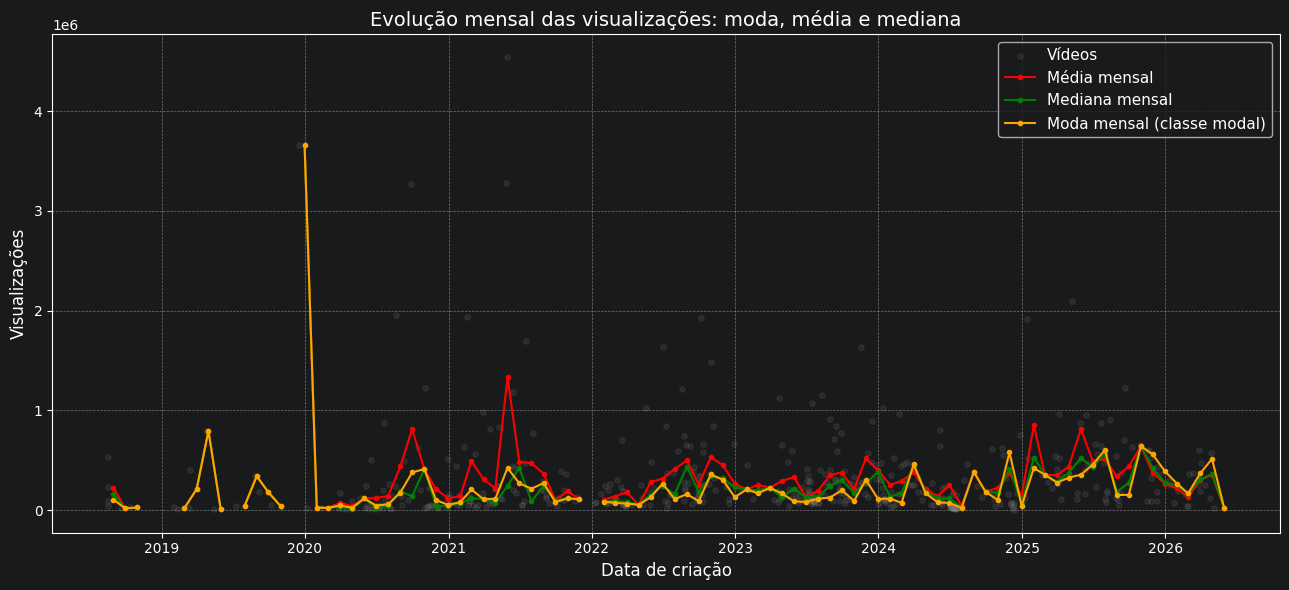

In [25]:
# Evolução temporal da moda, média e mediana das visualizações (agregadas por mês)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Série de visualizações indexada pela data e agregada por mês
serie = df.set_index('data_criacao')['views'].sort_index()
grupos = serie.resample('ME')

media_mes = grupos.mean()
mediana_mes = grupos.median()


# Moda mensal = centro da "classe modal" de cada mês (com poucos vídeos por mês é uma medida ruidosa)
def classe_modal(x):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    if len(x) < 3:                       # com pouquíssimos dados, cai para a mediana
        return x.median()
    contagens, bordas = np.histogram(x, bins=min(10, len(x)))
    i = contagens.argmax()
    return (bordas[i] + bordas[i + 1]) / 2


moda_mes = grupos.apply(classe_modal)

plt.figure(figsize=(13, 6))
# Dispersão dos vídeos ao fundo, apenas como contexto
plt.scatter(df['data_criacao'], df['views'], alpha=0.15, s=15, color='gray', label='Vídeos')

# As três medidas agora VARIAM no tempo (uma por mês)
plt.plot(media_mes.index,   media_mes.values,   color='red',    marker='o', ms=3, label='Média mensal')
plt.plot(mediana_mes.index, mediana_mes.values, color='green',  marker='o', ms=3, label='Mediana mensal')
plt.plot(moda_mes.index,    moda_mes.values,    color='orange', marker='o', ms=3, label='Moda mensal (classe modal)')

plt.title('Evolução mensal das visualizações: moda, média e mediana', fontsize=14)
plt.xlabel('Data de criação', fontsize=12)
plt.ylabel('Visualizações', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
